In [11]:
import numpy as np
import matplotlib.pyplot as plt

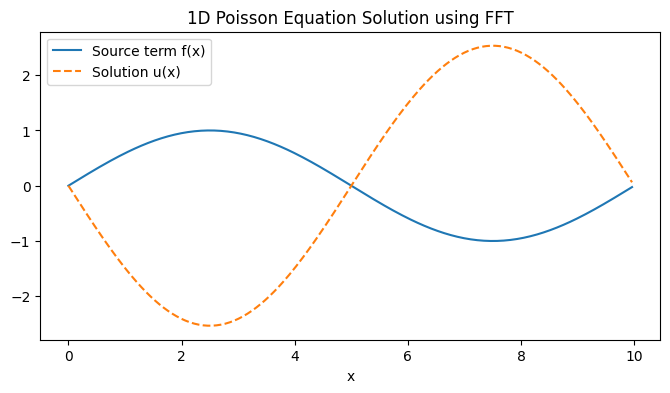

In [ ]:
# Define the grid
L = 10.0   # Domain length
N = 256    # Number of grid points
dx = L / N # Grid spacing
x = np.linspace(0, L, N, endpoint=False)

# Define the source term f(x) (example: a sine function)
f = np.sin(2 * np.pi * x / L)

# Compute Fourier Transform of f
f_hat = np.fft.fft(f)

# Define wave numbers
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)

# Solve for u_hat in Fourier space (avoiding division by zero for k=0)
u_hat = np.zeros_like(f_hat)
mask = k != 0
u_hat[mask] = -f_hat[mask] / (k[mask] ** 2)

# Compute inverse Fourier Transform to get u(x)
u = np.fft.ifft(u_hat).real  # Take real part

# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(x, f, label="Source term f(x)")
plt.plot(x, u, label="Solution u(x)", linestyle="dashed")
plt.xlabel("x")
plt.legend()
plt.title("1D Poisson Equation Solution using FFT")
plt.show()


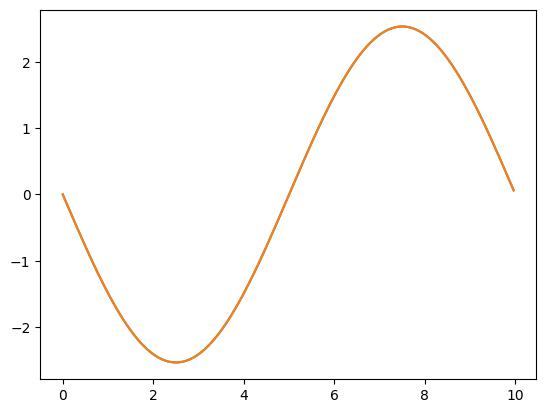

In [13]:
u_analytic = -(L/(2*np.pi))**2 * np.sin(2*np.pi*x/L)
plt.plot(x, u)
plt.plot(x, u_analytic)